In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib import rcParams


rcParams['font.family'] = 'SimHei'

In [2]:
df = pd.read_csv("../data/raw/may_filtered.csv")

In [3]:
datetimestr = df.date + ' ' + df.time
df['datetime'] = pd.to_datetime(datetimestr, format="%d-%m-%Y %H:%M:%S").astype('datetime64[s]')
df.ied = -1. * df.ied
df.drop(['date', 'time'], inplace=True, axis=1)

In [4]:
ied_diff = df['ied'].diff().abs()
df['magnitude'] = np.floor(np.log10(ied_diff.replace(0, np.nan))).fillna(-1)

In [5]:
import pandas as pd

is_zero = df.duration == '0:00:00'
# shift(-1) 会让最后一行变成 NaN，我们用 True 填充它，意思是“假设最后一行后面是0”
is_prev_not_zero = df.duration.shift(-1).fillna('0:00:00') == '0:00:00'

# 只要当前不是0且下一行是0，或者是数据集的最后一行
is_last_row = pd.Series(False, index=df.index)
is_last_row.iloc[-1] = True

# 组合条件：(当前不是0且下一行是0) 或 (是最后一行且它本身不是0)
reset_points = df[(~is_zero & is_prev_not_zero) | (is_last_row & ~is_zero)]

# 打印结果
for idx, row in reset_points.iterrows():
    print(f"索引: {idx}, 结束前最后时间: {row['duration']}")

索引: 1156575, 结束前最后时间: 1:56:19
索引: 2174741, 结束前最后时间: 2:56:14
索引: 2597882, 结束前最后时间: 1:21:24
索引: 5886578, 结束前最后时间: 10:08:58
索引: 7893799, 结束前最后时间: 6:23:05


In [6]:

# 1. 这是你刚才跑出来的 5 个重置前的最后一行索引
end_indices = [1156575, 2174741, 2597882, 5886578, 7893799]

slices = []
start = 0

for end in end_indices:
    # 使用 slice(start, end + 1) 是因为 Pandas 的 iloc 切片是“前闭后开”的
    # 这样写能确保切片刚好包含到 end 这一行
    slices.append(slice(start, end + 1))
    
    # 下一段的起点是当前终点的下一行
    start = end + 1

# 验证生成的切片数量
print(f"成功生成了 {len(slices)} 个片段的切片。\n")

# 预览每一个片段的范围
for i, slc in enumerate(slices):
    print(f"片段 {i+1}: iloc[{slc.start}:{slc.stop}] -> 包含数据行数: {slc.stop - slc.start}")

成功生成了 5 个片段的切片。

片段 1: iloc[0:1156576] -> 包含数据行数: 1156576
片段 2: iloc[1156576:2174742] -> 包含数据行数: 1018166
片段 3: iloc[2174742:2597883] -> 包含数据行数: 423141
片段 4: iloc[2597883:5886579] -> 包含数据行数: 3288696
片段 5: iloc[5886579:7893800] -> 包含数据行数: 2007221


In [7]:
# 1. 提取第 4 段数据（10小时08分的那一段）
df_part4 = df.iloc[slices[3]]
print(df_part4.head())

# 2. 循环遍历所有片段进行分析
for idx, slc in enumerate(slices):
    df_part = df.iloc[slc]
    # 在这里对每个片段进行你需要的操作，比如单独保存：
    # df_part.to_csv(f'part_{idx+1}.csv', index=False)

        duration         red         ied    accX   accY    accZ  \
2597883  0:00:00  15800537.0 -15329220.0  1839.0 -828.0  1092.0   
2597884  0:00:00  15803272.0 -15332104.0  1846.0 -856.0  1095.0   
2597885  0:00:00  15806286.0 -15335133.0  1824.0 -864.0  1084.0   
2597886  0:00:00  15808714.0 -15335339.0  1801.0 -876.0  1016.0   
2597887  0:00:00  15811223.0 -15338102.0  1730.0 -856.0  1002.0   

                   datetime  magnitude  
2597883 2026-05-03 02:00:20        6.0  
2597884 2026-05-03 02:00:20        3.0  
2597885 2026-05-03 02:00:20        3.0  
2597886 2026-05-03 02:00:20        2.0  
2597887 2026-05-03 02:00:20        3.0  


In [8]:
import pandas as pd
import numpy as np

# 1. 确保数据类型正确
df['datetime'] = pd.to_datetime(df['datetime'])
# 将 duration 转换为总秒数（float/int），更方便做数学差值计算
df['duration_secs'] = pd.to_timedelta(df['duration']).dt.total_seconds()

# 2. 打印精致的表头（分为 Datetime 组 和 Duration 组）
print(f"{'':<6} | {'--- Datetime 时长 ---':^25} | {'--- Duration 时长 ---':^25}")
print(f"{'片段':<6} | {'原始首尾差':<10} | {'去除间隔后':<10} | {'原始值':<10} | {'去除间隔后':<10}")
print("-" * 68)

for idx, slc in enumerate(slices):
    df_part = df.iloc[slc].copy()
    if len(df_part) == 0:
        continue
        
    # ==================== [ DATETIME 计算 ] ====================
    # 原始首尾差
    dt_raw_td = df_part['datetime'].iloc[-1] - df_part['datetime'].iloc[0]
    dt_raw_secs = dt_raw_td.total_seconds()
    
    # 去除间隔：因为是高频数据，先取去重后的秒级时间戳
    unique_dts = df_part['datetime'].drop_duplicates()
    # 计算去重后的相邻差值
    dt_diffs = unique_dts.diff().dt.total_seconds().fillna(0)
    # 只保留刚好等于 1 秒的正常跨秒，求和得到实际秒数
    dt_clean_secs = dt_diffs[dt_diffs == 1].sum()
    
    # ==================== [ DURATION 计算 ] ====================
    # 原始官方值（最后一行的累计值）
    dur_raw_secs = df_part['duration_secs'].iloc[-1]
    
    # 去除间隔：计算每行 duration 的增量
    dur_diffs = df_part['duration_secs'].diff().fillna(0)
    # 如果两行之间 duration 突变（比如设备卡顿后突然暴增超过 1 秒，或者出现负数异常）
    # 我们只累加正常的微小增量 (0 <= 增量 <= 1)
    dur_clean_secs = dur_diffs[(dur_diffs >= 0) & (dur_diffs <= 1)].sum()
    
    # ==================== [ 格式化为 00:00:00 ] ====================
    def to_hms(secs):
        h = int(secs // 3600)
        m = int((secs % 3600) // 60)
        s = int(secs % 60)
        return f"{h:02d}:{m:02d}:{s:02d}"

    print(f"片段 {idx+1:<2} | "
          f"{to_hms(dt_raw_secs):<10} | "
          f"{to_hms(dt_clean_secs):<10} | "
          f"{to_hms(dur_raw_secs):<10} | "
          f"{to_hms(dur_clean_secs):<10}")

       |    --- Datetime 时长 ---    |    --- Duration 时长 ---   
片段     | 原始首尾差      | 去除间隔后      | 原始值        | 去除间隔后     
--------------------------------------------------------------------
片段 1  | 01:56:20   | 01:37:55   | 01:56:19   | 01:37:56  
片段 2  | 02:56:13   | 02:50:07   | 02:56:14   | 02:50:09  
片段 3  | 01:21:24   | 01:11:42   | 01:21:24   | 01:11:46  
片段 4  | 10:08:59   | 09:11:48   | 10:08:58   | 09:11:50  
片段 5  | 06:23:07   | 05:37:00   | 06:23:05   | 05:37:48  


In [9]:
expanded_slices = []

for slc in slices:
    start_idx = slc.start
    end_idx = slc.stop  
    
    # 获取局部的 datetime 差值 和 magnitude
    local_diffs = df['datetime'].iloc[start_idx:end_idx].diff().dt.total_seconds().values
    local_mag = df['magnitude'].iloc[start_idx:end_idx].values
    
    # 寻找分割点：物理时间间隔 > 1s 或者 magnitude == 6
    # 首行 diff 默认是 NaN，所以不会被误判为分割点
    break_local_positions = np.where((local_diffs > 1) | (local_mag == 6))[0]
    
    # 将局部相对索引还原为 df 的全局绝对索引
    break_global_positions = start_idx + break_local_positions
    
    # 根据断点截出新的切片
    current_start = start_idx
    for bp in break_global_positions:
        expanded_slices.append(slice(current_start, bp))
        current_start = bp
        
    # 收尾该大片段的最后一部分
    if current_start < end_idx:
        expanded_slices.append(slice(current_start, end_idx))


# ==================== [ 5. 丢弃时间跨度不足 1 秒的片段 ] ====================
final_valid_slices = []

for slc in expanded_slices:
    df_sub = df.iloc[slc]
    
    # 规避空切片
    if len(df_sub) == 0:
        continue
        
    # 计算该片段首尾的物理时间差
    time_span = (df_sub['datetime'].iloc[-1] - df_sub['datetime'].iloc[0]).total_seconds()
    
    # 只有跨度 >= 1 秒的片段才保留
    # 如果数据全都挤在同一秒内 (首尾相减为 0)，则丢弃
    if time_span >= 1:
        final_valid_slices.append(slc)

# --- 打印结果与对比 ---
print(f"依据双条件拆分后，初步产生: {len(expanded_slices)} 个子片段")
print(f"剔除不足 1 秒的废帧后，最终保留: {len(final_valid_slices)} 个有效子片段")

# 预览一下最终留下的片段状态
if len(final_valid_slices) > 0:
    print("\n前 3 个有效子片段预览:")
    for i, slc in enumerate(final_valid_slices[:3]):
        span = (df['datetime'].iloc[slc.stop-1] - df['datetime'].iloc[slc.start]).total_seconds()
        print(f"  片段 {i+1}: iloc[{slc.start}:{slc.stop}] | 行数: {slc.stop - slc.start} | 跨度: {span} 秒")

依据双条件拆分后，初步产生: 481 个子片段
剔除不足 1 秒的废帧后，最终保留: 346 个有效子片段

前 3 个有效子片段预览:
  片段 1: iloc[0:36780] | 行数: 36780 | 跨度: 184.0 秒
  片段 2: iloc[36780:107065] | 行数: 70285 | 跨度: 352.0 秒
  片段 3: iloc[107075:142160] | 行数: 35085 | 跨度: 175.0 秒


In [10]:
clean_slices = [
    slice(
        int(slc.start) if slc.start is not None else None, 
        int(slc.stop) if slc.stop is not None else None, 
        int(slc.step) if slc.step is not None else None
    ) 
    for slc in final_valid_slices
]

In [11]:

slice_durations = []
total_seconds = 0

for idx, slc in enumerate(clean_slices):
    # slc.stop 是开区间，所以片段的最后一行索引是 slc.stop - 1
    start_time = df['datetime'].iloc[slc.start]
    end_time = df['datetime'].iloc[slc.stop - 1]
    
    # 计算当前片段的物理时长
    duration = end_time - start_time
    duration_secs = duration.total_seconds()
    
    # 累加到总时长
    total_seconds += duration_secs
    
    # 记录该片段的信息
    slice_durations.append({
        '片段序号': idx + 1,
        '开始索引': slc.start,
        '结束索引': slc.stop,
        '行数': slc.stop - slc.start,
        '时长(秒)': duration_secs,
        '时长(格式化)': str(duration).replace('0 days ', '')
    })

# 转化为 DataFrame 方便查看和后续分析
df_durations = pd.DataFrame(slice_durations)

# 将总秒数转换为时分秒的 Timedelta 格式
total_duration_td = pd.to_timedelta(total_seconds, unit='s')

# --- 打印统计结果 ---
print(f"✅ 成功统计了 {len(clean_slices)} 个有效连续片段。")
print("=" * 60)
print(f"🚀 所有片段有效总时长 : {str(total_duration_td).replace('0 days ', '')}")
print(f"   (折合总秒数)      : {total_seconds:.0f} 秒")
print(f"   (折合总小时数)    : {total_seconds / 3600:.2f} 小时")
print("=" * 60)

# 打印各片段明细（如果片段太多，这里只展示前 15 个和最后 5 个）
print("\n--- 各片段时长明细预览 ---")
if len(df_durations) > 20:
    print(df_durations.head(15).to_string(index=False))
    print("...")
    print(df_durations.tail(5).to_string(index=False))
else:
    print(df_durations.to_string(index=False))

✅ 成功统计了 346 个有效连续片段。
🚀 所有片段有效总时长 : 20:27:52
   (折合总秒数)      : 73672 秒
   (折合总小时数)    : 20.46 小时

--- 各片段时长明细预览 ---
 片段序号   开始索引   结束索引     行数  时长(秒)  时长(格式化)
    1      0  36780  36780  184.0 00:03:04
    2  36780 107065  70285  352.0 00:05:52
    3 107075 142160  35085  175.0 00:02:55
    4 142160 160038  17878   90.0 00:01:30
    5 160048 231129  71081  356.0 00:05:56
    6 231140 301187  70047  350.0 00:05:50
    7 301198 436004 134806  675.0 00:11:15
    8 436015 470966  34951  175.0 00:02:55
    9 470977 480787   9810   49.0 00:00:49
   10 480798 485784   4986   25.0 00:00:25
   11 485795 829558 343763 1728.0 00:28:48
   12 829558 829858    300    3.0 00:00:03
   13 829858 830138    280    8.0 00:00:08
   14 830138 895556  65418  329.0 00:05:29
   15 895556 895720    164    1.0 00:00:01
...
 片段序号    开始索引    结束索引     行数  时长(秒)  时长(格式化)
  342 7700886 7702549   1663   19.0 00:00:19
  343 7702549 7702551      2    1.0 00:00:01
  344 7702574 7706607   4033   41.0 00:00:41
  345 7706607

In [12]:
df_durations

,片段序号,开始索引,结束索引,行数,时长(秒),时长(格式化)
0,1,0,36780,36780,184.0,00:03:04
1,2,36780,107065,70285,352.0,00:05:52
2,3,107075,142160,35085,175.0,00:02:55
3,4,142160,160038,17878,90.0,00:01:30
4,5,160048,231129,71081,356.0,00:05:56
...,...,...,...,...,...,...
341,342,7700886,7702549,1663,19.0,00:00:19
342,343,7702549,7702551,2,1.0,00:00:01
343,344,7702574,7706607,4033,41.0,00:00:41
344,345,7706607,7707437,830,8.0,00:00:08


In [13]:
# 假设你是用 value_counts() 统计的
counts = df_durations['时长(秒)'].value_counts().sort_index()
# print(counts.to_string())

In [14]:
# 过滤出时长 >= 10秒 的切片
long_slices = []

for slc in clean_slices:
    start_time = df['datetime'].iloc[slc.start]
    end_time = df['datetime'].iloc[slc.stop - 1]
    
    duration_secs = int((end_time - start_time).total_seconds())
    
    # 只要时长大于等于 10 秒就保留
    if duration_secs >= 10:
        long_slices.append(slc)

print(f"原片段数量: {len(clean_slices)}")
print(f"去除 <10s 后剩余数量: {len(long_slices)}")

# 如果你想顺便更新前面的 df_durations 统计表：
# 可以直接利用 DataFrame 的条件过滤，这样更方便查看明细
df_long_durations = df_durations[df_durations['时长(秒)'] >= 10].reset_index(drop=True)

# 打印过滤后的总览
total_long_secs = df_long_durations['时长(秒)'].sum()
print("\n--- 过滤后的数据概况 ---")
print(f"剩余总片段数 : {len(long_slices)}")
print(f"剩余有效总时长 : {pd.to_timedelta(total_long_secs, unit='s')}")

原片段数量: 346
去除 <10s 后剩余数量: 220

--- 过滤后的数据概况 ---
剩余总片段数 : 220
剩余有效总时长 : 0 days 20:20:25


In [15]:
import pandas as pd
import numpy as np
import neurokit2 as nk

# ⚠️ 脉搏波列名
ppg_col = 'ied'

# 在全局 df 中创建特征列，默认全部为 0
df['is_peak'] = 0
df['is_trough'] = 0

all_peaks_global = []
all_troughs_global = []

# 用于保存分流后的切片列表
high_quality_slices = []
discarded_slices = []

print(f"开始处理 {len(long_slices)} 个有效片段...\n")

for idx, slc in enumerate(long_slices):
    df_sub = df.iloc[slc]
    
    # 1. 动态计算当前片段的采样率 (Hz)
    time_span = (df_sub['datetime'].iloc[-1] - df_sub['datetime'].iloc[0]).total_seconds()
    fs = int(np.round(len(df_sub) / time_span))
    
    # ==================== [ 新增：极低采样率过滤 ] ====================
    if fs < 60:
        discarded_slices.append(slc)
        # 低频片段直接跳过特征提取
        continue
    
    # 采样率达标，存入高质量列表
    high_quality_slices.append(slc)
    # ================================================================

    raw_ppg = df_sub[ppg_col].values
    
    try:
        # 2. 清洗滤波
        ppg_cleaned = nk.ppg_clean(raw_ppg, sampling_rate=fs)
        
        # 3. 寻找真正的波峰 (Systolic Peaks)
        info_peaks = nk.ppg_findpeaks(ppg_cleaned, sampling_rate=fs)
        peaks_local = info_peaks['PPG_Peaks']
        
        # 4. 寻找波谷 (Troughs / Onsets)
        # 将信号反相，利用通用的信号波峰提取函数找出所有的"局部最低点"
        info_all_troughs = nk.signal_findpeaks(-ppg_cleaned)
        all_troughs_local = info_all_troughs['Peaks']
        
        troughs_local = []
        # 生理学逻辑：每次心跳的波谷，都出现在波峰的正前方
        for peak in peaks_local:
            # 找到所有发生在当前波峰之前的波谷
            valid_troughs = [t for t in all_troughs_local if t < peak]
            if len(valid_troughs) > 0:
                # 距离波峰最近的那一个（也就是列表里的最后一个），就是准确的起点
                troughs_local.append(valid_troughs[-1])
                
        # 5. 局部索引转全局绝对索引
        peaks_global = slc.start + np.array(peaks_local)
        troughs_global = slc.start + np.array(troughs_local)
        
        all_peaks_global.extend(peaks_global)
        all_troughs_global.extend(troughs_global)
        
        if (idx + 1) % 20 == 0 or (idx + 1) == len(long_slices):
            print(f"已处理 {idx + 1}/{len(long_slices)} 个片段 | 当前采样率: {fs} Hz")
            
    except Exception as e:
        print(f"⚠️ 片段 {idx + 1} (iloc[{slc.start}:{slc.stop}]) 提取失败，原因: {e}")

# ==================== [ 全局打标 ] ====================
# 只有高质量片段的波峰/波谷才会被标记为 1
if len(all_peaks_global) > 0:
    df.loc[all_peaks_global, 'is_peak'] = 1
if len(all_troughs_global) > 0:
    df.loc[all_troughs_global, 'is_trough'] = 1

print("\n" + "=" * 50)
print(f"🎉 特征提取与过滤完毕！")
print(f"📉 剔除低采样片段: {len(discarded_slices)} 个 (< 60 Hz)")
print(f"📈 保留高质量片段: {len(high_quality_slices)} 个 (>= 60 Hz)")
print("-" * 50)
print(f"👉 共提取波峰 (Peaks):   {len(all_peaks_global)} 个")
print(f"👉 共提取波谷 (Troughs): {len(all_troughs_global)} 个")
print("=" * 50)

开始处理 220 个有效片段...

已处理 20/220 个片段 | 当前采样率: 207 Hz
已处理 40/220 个片段 | 当前采样率: 98 Hz
已处理 60/220 个片段 | 当前采样率: 97 Hz
已处理 80/220 个片段 | 当前采样率: 100 Hz
已处理 100/220 个片段 | 当前采样率: 96 Hz
已处理 120/220 个片段 | 当前采样率: 100 Hz
已处理 160/220 个片段 | 当前采样率: 98 Hz
已处理 180/220 个片段 | 当前采样率: 100 Hz
已处理 200/220 个片段 | 当前采样率: 102 Hz
已处理 220/220 个片段 | 当前采样率: 100 Hz

🎉 特征提取与过滤完毕！
📉 剔除低采样片段: 9 个 (< 60 Hz)
📈 保留高质量片段: 211 个 (>= 60 Hz)
--------------------------------------------------
👉 共提取波峰 (Peaks):   67996 个
👉 共提取波谷 (Troughs): 67993 个


In [16]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

# ========== 修复负号显示报错 ==========
plt.rcParams['axes.unicode_minus'] = False  
ppg_col = 'ied'

def plot_interactive_segment_raw(segment_idx, start_sec, window_sec):
    # 1. 提取当前片段
    slc = high_quality_slices[segment_idx]
    df_sub = df.iloc[slc]
    
    # 2. 计算当前片段的局部采样率
    time_span = (df_sub['datetime'].iloc[-1] - df_sub['datetime'].iloc[0]).total_seconds()
    fs = int(np.round(len(df_sub) / time_span))
    
    # 3. 直接获取纯原始信号 (不进行任何滤波)
    raw_ppg = df_sub[ppg_col].values
    
    # 4. 将时间（秒）转换为索引行数
    start_idx = int(start_sec * fs)
    window_rows = int(window_sec * fs)
    end_idx = min(start_idx + window_rows, len(df_sub))
    
    # 截取当前展示窗口
    window_raw = raw_ppg[start_idx:end_idx]
    
    # 生成 X 轴时间刻度
    x_time = np.arange(start_idx, end_idx) / fs
    
    # ==================== 开始绘图 ====================
    plt.figure(figsize=(15, 5))
    
    # 只画出原始信号 (换成清晰的蓝色实线)
    plt.plot(x_time, window_raw, color='#1f77b4', label='Raw Signal (Unfiltered)', linewidth=1.5)
    
    plt.title(f"Raw Segment Observation: {segment_idx + 1} / {len(high_quality_slices)} | fs = {fs} Hz")
    plt.xlabel("Time (seconds) from segment start")
    plt.ylabel("Amplitude")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # ==================== 🔥 核心修正：Y 轴局部自适应 ====================
    if len(window_raw) > 0 and not np.isnan(window_raw).all():
        # 仅仅基于【当前窗口内】的极值来计算上下限
        y_min, y_max = np.nanmin(window_raw), np.nanmax(window_raw)
        margin = (y_max - y_min) * 0.1
        if margin == 0: margin = 1 
        plt.ylim(y_min - margin, y_max + margin)
    # ====================================================================
    
    plt.tight_layout()
    plt.show()

# ==================== [ 构建交互式 UI ] ====================

# 定义滑块
segment_slider = widgets.IntSlider(min=0, max=len(high_quality_slices)-1, step=1, value=0, description='选择片段:', layout=widgets.Layout(width='600px'))
window_slider = widgets.IntSlider(min=3, max=30, step=1, value=10, description='窗口宽度(秒):', layout=widgets.Layout(width='600px'))
pan_slider = widgets.FloatSlider(min=0.0, max=100.0, step=1.0, value=0.0, description='平移进度(秒):', layout=widgets.Layout(width='600px'))

# 动态调整平移滑块的范围
def update_pan_range(*args):
    slc = high_quality_slices[segment_slider.value]
    df_sub = df.iloc[slc]
    time_span = (df_sub['datetime'].iloc[-1] - df_sub['datetime'].iloc[0]).total_seconds()
    
    # 允许的最大拖动距离
    max_pan = max(0.0, time_span - window_slider.value)
    pan_slider.max = max_pan
    
    # 如果是切换了新片段，进度条自动归零
    if args and args[0]['owner'] == segment_slider:
        pan_slider.value = 0.0
    else:
        pan_slider.value = min(pan_slider.value, max_pan)

# 绑定联动事件
segment_slider.observe(update_pan_range, 'value')
window_slider.observe(update_pan_range, 'value')
update_pan_range()

# 启动面板
out = widgets.interact(
    plot_interactive_segment_raw,
    segment_idx=segment_slider,
    start_sec=pan_slider,
    window_sec=window_slider
)

interactive(children=(IntSlider(value=0, description='选择片段:', layout=Layout(width='600px'), max=210), FloatSli…

In [17]:
import pandas as pd
import numpy as np
pd.set_option('display.unicode.east_asian_width', True)

# ⚠️ 设定你的目标标称采样率 (一般穿戴设备 PPG 是 100 Hz 或 128 Hz)
# 请根据你的实际设备参数修改
TARGET_FS = 100 

# 设定允许的误差阈值 (例如 1% 的浮动)
TOLERANCE = 0.01 

resample_reports = []

for idx, slc in enumerate(high_quality_slices):
    df_sub = df.iloc[slc]
    
    # 精确计算时间跨度
    time_span = (df_sub['datetime'].iloc[-1] - df_sub['datetime'].iloc[0]).total_seconds()
    
    # 规避极短或者时间跨度为0的异常情况
    if time_span <= 0:
        continue
        
    n_samples = len(df_sub)
    
    # 计算精确的浮点型采样率
    exact_fs = n_samples / time_span
    
    # 计算与目标的偏离比例
    deviation = abs(exact_fs - TARGET_FS) / TARGET_FS
    
    # 判断是否需要重采样的两个条件：
    # 1. 实际采样率与目标采样率偏差超过了设定的容忍度
    # 2. 或者精确采样率不是一个完美的整数 (说明在整秒内存在极其微小的漏帧/多帧)
    needs_resampling = (deviation > TOLERANCE) or not exact_fs.is_integer()
    
    resample_reports.append({
        '片段序号': idx + 1,
        '总行数': n_samples,
        '时长(秒)': int(time_span),
        '精确采样率(Hz)': round(exact_fs, 3),
        '偏离比例': f"{deviation*100:.2f}%",
        '是否需重采样': needs_resampling
    })

df_resample_check = pd.DataFrame(resample_reports)

# ==================== [ 打印检测概况 ] ====================
needs_count = df_resample_check['是否需重采样'].sum()
print(f"总评估片段数: {len(df_resample_check)}")
print("-" * 30)
print(f"⚠️ 必须重采样的片段数: {needs_count}")
print(f"✅ 无需重采样的片段数: {len(df_resample_check) - needs_count}")
print("-" * 30)

# 查看需要重采样的片段明细 (按偏离程度从大到小排序)
if needs_count > 0:
    bad_fs_df = df_resample_check[df_resample_check['是否需重采样']].sort_values(by='偏离比例', ascending=False)
    print("\n--- 偏差最大的前 10 个片段预览 ---")
    print(bad_fs_df.head(10).to_string(index=False))


# 1. 打印统计学描述（均值、中位数、最小/最大值）
print("--- 211个片段的精确采样率统计 ---")
print(df_resample_check['精确采样率(Hz)'].describe())

# 2. 将采样率分箱，看看它们到底集中在哪个区间
bins = [0, 60, 90, 110, 150, 190, 210, 300]
labels = ['<60 (极低)', '60-90 (异常)', '90-110 (约100Hz)', '110-150 (异常)', '150-190 (异常)', '190-210 (约200Hz)', '>210']

# 统计各个区间内的片段数量
distribution = pd.cut(df_resample_check['精确采样率(Hz)'], bins=bins, labels=labels).value_counts().sort_index()

print("\n--- 采样率全局区间分布 ---")
print(distribution.to_string())

总评估片段数: 211
------------------------------
⚠️ 必须重采样的片段数: 209
✅ 无需重采样的片段数: 2
------------------------------

--- 偏差最大的前 10 个片段预览 ---
 片段序号  总行数  时长(秒)  精确采样率(Hz) 偏离比例  是否需重采样
        1   36780       184         199.891   99.89%          True
        8   34951       175         199.720   99.72%          True
        7  134806       675         199.713   99.71%          True
        5   71081       356         199.666   99.67%          True
        2   70285       352         199.673   99.67%          True
       10    4986        25         199.440   99.44%          True
       22   18145        91         199.396   99.40%          True
       11  343763      1728         198.937   98.94%          True
       12   65418       329         198.839   98.84%          True
        4   17878        90         198.644   98.64%          True
--- 211个片段的精确采样率统计 ---
count    211.00000
mean     105.81063
std       28.99578
min       59.56500
25%       97.73050
50%       99.79700
75%      100.28600


In [18]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d

# 🎯 铁证如山，设定目标采样率为 100 Hz
TARGET_FS = 100 
ppg_col = 'ied'

resampled_segments = []

print(f"开始将 {len(high_quality_slices)} 个高质量片段对齐至绝对 {TARGET_FS} Hz...")

for idx, slc in enumerate(high_quality_slices):
    df_sub = df.iloc[slc]
    
    orig_y = df_sub[ppg_col].values
    n_samples = len(orig_y)
    
    start_time = df_sub['datetime'].iloc[0]
    time_span = (df_sub['datetime'].iloc[-1] - start_time).total_seconds()
    
    if time_span <= 0:
        continue
        
    # 构造原时间轴和新时间轴
    orig_x = np.linspace(0, time_span, n_samples)
    step = 1.0 / TARGET_FS
    new_x = np.arange(0, time_span, step)
    
    # 使用 interp1d 进行高速重采样 (kind='cubic' 保持三次平滑)
    f_interp = interp1d(orig_x, orig_y, kind='cubic', assume_sorted=True, fill_value="extrapolate")
    new_y = f_interp(new_x)
    
    # 重建毫秒级精度的 datetime 时间戳 (每行严格相差 0.01 秒)
    new_datetime = start_time + pd.to_timedelta(new_x, unit='s')
    
    # 组装成纯净的数据块
    df_clean = pd.DataFrame({
        'datetime': new_datetime,
        ppg_col: new_y
    })
    
    resampled_segments.append(df_clean)

print("=" * 50)
print(f"🎉 全部重采样完成！成功生成 {len(resampled_segments)} 个 {TARGET_FS} Hz 的纯净数据块。")
print("=" * 50)

开始将 211 个高质量片段对齐至绝对 100 Hz...
🎉 全部重采样完成！成功生成 211 个 100 Hz 的纯净数据块。


In [19]:
# ========== 修复负号显示报错 ==========
plt.rcParams['axes.unicode_minus'] = False  
ppg_col = 'ied'
TARGET_FS = 100 

def plot_interactive_resampled(segment_idx, start_sec, window_sec):
    # 1. 提取当前重采样后的纯净片段
    df_sub = resampled_segments[segment_idx]
    
    # 2. 获取信号
    clean_ppg = df_sub[ppg_col].values
    
    # 3. 将时间（秒）转换为索引行数 (因为是纯净 100Hz，直接乘即可)
    start_idx = int(start_sec * TARGET_FS)
    window_rows = int(window_sec * TARGET_FS)
    end_idx = min(start_idx + window_rows, len(df_sub))
    
    # 截取当前展示窗口
    window_clean = clean_ppg[start_idx:end_idx]
    
    # 生成 X 轴时间刻度 (相对该片段开始的秒数)
    x_time = np.arange(start_idx, end_idx) / TARGET_FS
    
    # ==================== 开始绘图 ====================
    plt.figure(figsize=(15, 5))
    
    # 画出重采样后的平滑信号 (使用绿色代表通过了插值处理的纯净信号)
    plt.plot(x_time, window_clean, color='#2ca02c', label='Resampled Signal (Strictly 100 Hz)', linewidth=1.5)
    
    plt.title(f"Resampled Segment: {segment_idx + 1} / {len(resampled_segments)} | Pure 100 Hz")
    plt.xlabel("Time (seconds) from segment start")
    plt.ylabel("Amplitude")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # ==================== Y 轴局部自适应 ====================
    if len(window_clean) > 0 and not np.isnan(window_clean).all():
        y_min, y_max = np.nanmin(window_clean), np.nanmax(window_clean)
        margin = (y_max - y_min) * 0.1
        if margin == 0: margin = 1 
        plt.ylim(y_min - margin, y_max + margin)
    
    plt.tight_layout()
    plt.show()

# ==================== [ 构建交互式 UI ] ====================

# 定义滑块
segment_slider = widgets.IntSlider(min=0, max=len(resampled_segments)-1, step=1, value=0, description='选择片段:', layout=widgets.Layout(width='600px'))
window_slider = widgets.IntSlider(min=3, max=30, step=1, value=10, description='窗口宽度(秒):', layout=widgets.Layout(width='600px'))
pan_slider = widgets.FloatSlider(min=0.0, max=100.0, step=1.0, value=0.0, description='平移进度(秒):', layout=widgets.Layout(width='600px'))

# 动态调整平移滑块的范围
def update_pan_range(*args):
    df_sub = resampled_segments[segment_slider.value]
    
    # 因为已经是完美的 100Hz，总秒数极速计算：行数 / 100
    time_span = len(df_sub) / TARGET_FS
    
    # 允许的最大拖动距离
    max_pan = max(0.0, time_span - window_slider.value)
    pan_slider.max = max_pan
    
    # 如果是切换了新片段，进度条自动归零
    if args and args[0]['owner'] == segment_slider:
        pan_slider.value = 0.0
    else:
        pan_slider.value = min(pan_slider.value, max_pan)

# 绑定联动事件
segment_slider.observe(update_pan_range, 'value')
window_slider.observe(update_pan_range, 'value')

# 初始化一下滑块上限
update_pan_range()

# 启动面板
out = widgets.interact(
    plot_interactive_resampled,
    segment_idx=segment_slider,
    start_sec=pan_slider,
    window_sec=window_slider
)

interactive(children=(IntSlider(value=0, description='选择片段:', layout=Layout(width='600px'), max=210), FloatSli…

In [20]:
# 现在，信号已经，处理每个片段里面的基线漂移，运动伪影等问题。也可以说是AC，DC信号分离。给出代码

开始对 211 个片段进行 AC/DC 信号分离...
✅ 已处理 20/211 个片段
✅ 已处理 40/211 个片段
✅ 已处理 60/211 个片段
✅ 已处理 80/211 个片段
✅ 已处理 100/211 个片段
✅ 已处理 120/211 个片段
✅ 已处理 140/211 个片段
✅ 已处理 160/211 个片段
✅ 已处理 180/211 个片段
✅ 已处理 200/211 个片段
✅ 已处理 211/211 个片段
🎉 信号分离完成！所有片段均已添加 'ac_signal' 和 'dc_signal' 列。


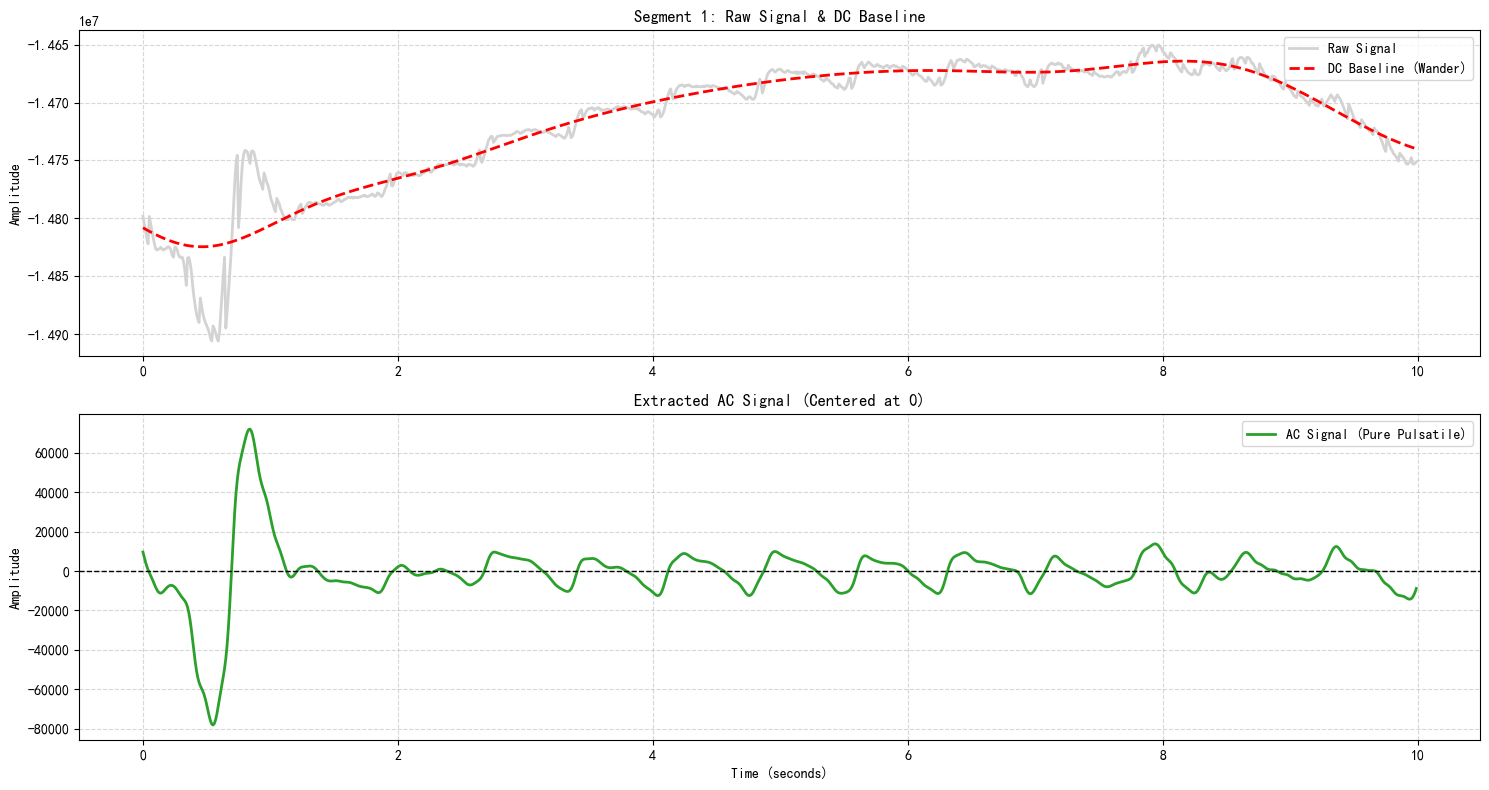

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# 设置参数
TARGET_FS = 100 
ppg_col = 'ied'

def separate_ac_dc(signal, fs):
    """
    使用 4 阶零相移巴特沃斯滤波器进行交直流分离
    """
    # 1. 提取 DC 基线 (低通滤波，保留 0.5 Hz 以下的极低频变化)
    b_low, a_low = butter(4, 0.5, btype='lowpass', fs=fs)
    dc_signal = filtfilt(b_low, a_low, signal)
    
    # 2. 提取 AC 脉搏波 (带通滤波，保留 0.5 Hz 到 8 Hz 的核心心跳频段)
    # 这样既滤除了基线漂移，又顺手抹平了 8Hz 以上的高频运动毛刺
    b_band, a_band = butter(4, [0.5, 8.0], btype='bandpass', fs=fs)
    ac_signal = filtfilt(b_band, a_band, signal)
    
    return ac_signal, dc_signal

print(f"开始对 {len(resampled_segments)} 个片段进行 AC/DC 信号分离...")

for idx, df_sub in enumerate(resampled_segments):
    raw_signal = df_sub[ppg_col].values
    
    # 执行分离
    ac_sig, dc_sig = separate_ac_dc(raw_signal, TARGET_FS)
    
    # 将分离后的信号存回 DataFrame
    df_sub['ac_signal'] = ac_sig
    df_sub['dc_signal'] = dc_sig
    
    if (idx + 1) % 20 == 0 or (idx + 1) == len(resampled_segments):
        print(f"✅ 已处理 {idx + 1}/{len(resampled_segments)} 个片段")

print("=" * 50)
print("🎉 信号分离完成！所有片段均已添加 'ac_signal' 和 'dc_signal' 列。")
print("=" * 50)

# ==================== [ 抽查可视化验证 ] ====================
# 画出第一个片段的前 10 秒，让你直观地看看分离效果
test_idx = 0
df_test = resampled_segments[test_idx].head(TARGET_FS * 10) 

x_time = np.arange(len(df_test)) / TARGET_FS

plt.figure(figsize=(15, 8))

# 图 1：原始信号与提取出的 DC 基线
plt.subplot(2, 1, 1)
plt.plot(x_time, df_test[ppg_col], color='lightgray', label='Raw Signal', linewidth=2)
plt.plot(x_time, df_test['dc_signal'], color='red', label='DC Baseline (Wander)', linewidth=2, linestyle='--')
plt.title(f"Segment {test_idx + 1}: Raw Signal & DC Baseline")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

# 图 2：剥离了基线和毛刺后的纯净 AC 信号
plt.subplot(2, 1, 2)
plt.plot(x_time, df_test['ac_signal'], color='#2ca02c', label='AC Signal (Pure Pulsatile)', linewidth=2)
# 画一条 0 刻度线，你会发现 AC 信号完美地围绕 0 轴上下对称波动
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.title("Extracted AC Signal (Centered at 0)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [22]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

# ========== 修复负号显示报错 ==========
plt.rcParams['axes.unicode_minus'] = False  
ppg_col = 'ied'
TARGET_FS = 100 

def plot_interactive_acdc(segment_idx, start_sec, window_sec):
    # 1. 提取当前片段
    df_sub = resampled_segments[segment_idx]
    
    # 2. 将时间（秒）转换为索引行数
    start_idx = int(start_sec * TARGET_FS)
    window_rows = int(window_sec * TARGET_FS)
    end_idx = min(start_idx + window_rows, len(df_sub))
    
    # 3. 截取当前展示窗口的信号
    window_raw = df_sub[ppg_col].values[start_idx:end_idx]
    window_dc = df_sub['dc_signal'].values[start_idx:end_idx]
    window_ac = df_sub['ac_signal'].values[start_idx:end_idx]
    
    # 4. 生成 X 轴时间刻度
    x_time = np.arange(start_idx, end_idx) / TARGET_FS
    
    # ==================== 开始绘图 ====================
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    
    # -------- 上半部分：原始信号与 DC 基线 --------
    ax1.plot(x_time, window_raw, color='lightgray', label='Original Resampled Signal', linewidth=2)
    ax1.plot(x_time, window_dc, color='red', label='DC Baseline (Wander)', linewidth=2, linestyle='--')
    ax1.set_title(f"Segment {segment_idx + 1} / {len(resampled_segments)} | Raw Signal vs DC Baseline")
    ax1.set_ylabel("Amplitude")
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # 上半部分的 Y 轴局部自适应
    if len(window_raw) > 0 and not np.isnan(window_raw).all():
        y_min1, y_max1 = np.nanmin(window_raw), np.nanmax(window_raw)
        margin1 = (y_max1 - y_min1) * 0.1 if (y_max1 - y_min1) != 0 else 1
        ax1.set_ylim(y_min1 - margin1, y_max1 + margin1)

    # -------- 下半部分：分离出的 AC 纯净搏动 --------
    ax2.plot(x_time, window_ac, color='#2ca02c', label='AC Signal (Pure Pulsatile)', linewidth=1.5)
    ax2.axhline(0, color='black', linewidth=1, linestyle='--') # 0刻度基准线
    ax2.set_title("Extracted AC Signal (Centered at 0)")
    ax2.set_xlabel("Time (seconds) from segment start")
    ax2.set_ylabel("Amplitude")
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    # 下半部分的 Y 轴局部自适应
    if len(window_ac) > 0 and not np.isnan(window_ac).all():
        y_min2, y_max2 = np.nanmin(window_ac), np.nanmax(window_ac)
        margin2 = (y_max2 - y_min2) * 0.1 if (y_max2 - y_min2) != 0 else 1
        ax2.set_ylim(y_min2 - margin2, y_max2 + margin2)
    
    plt.tight_layout()
    plt.show()

# ==================== [ 构建交互式 UI ] ====================

segment_slider = widgets.IntSlider(min=0, max=len(resampled_segments)-1, step=1, value=0, description='选择片段:', layout=widgets.Layout(width='600px'))
window_slider = widgets.IntSlider(min=3, max=30, step=1, value=10, description='窗口宽度(秒):', layout=widgets.Layout(width='600px'))
pan_slider = widgets.FloatSlider(min=0.0, max=100.0, step=1.0, value=0.0, description='平移进度(秒):', layout=widgets.Layout(width='600px'))

# 动态调整平移滑块的范围
def update_pan_range(*args):
    df_sub = resampled_segments[segment_slider.value]
    time_span = len(df_sub) / TARGET_FS
    
    max_pan = max(0.0, time_span - window_slider.value)
    pan_slider.max = max_pan
    
    if args and args[0]['owner'] == segment_slider:
        pan_slider.value = 0.0
    else:
        pan_slider.value = min(pan_slider.value, max_pan)

segment_slider.observe(update_pan_range, 'value')
window_slider.observe(update_pan_range, 'value')
update_pan_range()

out = widgets.interact(
    plot_interactive_acdc,
    segment_idx=segment_slider,
    start_sec=pan_slider,
    window_sec=window_slider
)

interactive(children=(IntSlider(value=0, description='选择片段:', layout=Layout(width='600px'), max=210), FloatSli…

In [23]:
import neurokit2 as nk
import pandas as pd
import numpy as np

QUALITY_THRESHOLD = 0.5 

total_duration_sec = 0
bad_duration_sec = 0

print(f"开始对 {len(resampled_segments)} 个片段进行模板匹配质量评估 (带防崩溃机制)...")

for idx, df_sub in enumerate(resampled_segments):
    ac_sig = df_sub['ac_signal'].values
    
    try:
        # 尝试进行质量评估
        quality_scores = nk.ppg_quality(ac_sig, sampling_rate=TARGET_FS)
        quality_scores = np.nan_to_num(quality_scores, nan=0.0)
        
    except Exception as e:
        # 如果烂到连模板都算不出来，直接全段判死刑
        print(f"  ⚠️ 片段 {idx + 1} 质量极度恶劣，算法拒绝评估，已全段标记为劣质。({type(e).__name__})")
        quality_scores = np.zeros(len(ac_sig))
    
    # 记录分数与布尔掩码
    df_sub['sqi_score'] = quality_scores
    df_sub['is_valid'] = quality_scores >= QUALITY_THRESHOLD
    
    segment_len_sec = len(df_sub) / TARGET_FS
    bad_len_sec = (~df_sub['is_valid']).sum() / TARGET_FS
    
    total_duration_sec += segment_len_sec
    bad_duration_sec += bad_len_sec

good_duration_sec = total_duration_sec - bad_duration_sec

print("\n" + "=" * 50)
print("✅ 信号质量评估 (SQA) 完毕！")
print(f"👉 信号总时长: {total_duration_sec / 3600:.2f} 小时")
print(f"🌟 高质量信号 (True): {good_duration_sec / 3600:.2f} 小时 ({good_duration_sec/total_duration_sec*100:.1f}%)")
print(f"🗑️ 劣质运动伪影 (False): {bad_duration_sec / 3600:.2f} 小时 ({bad_duration_sec/total_duration_sec*100:.1f}%)")
print("=" * 50)

开始对 211 个片段进行模板匹配质量评估 (带防崩溃机制)...


D:\miniforge\envs\feature_pipeline\Lib\site-packages\neurokit2\signal\signal_period.py:83: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(


  ⚠️ 片段 22 质量极度恶劣，算法拒绝评估，已全段标记为劣质。(ValueError)

✅ 信号质量评估 (SQA) 完毕！
👉 信号总时长: 20.30 小时
🌟 高质量信号 (True): 16.49 小时 (81.2%)
🗑️ 劣质运动伪影 (False): 3.81 小时 (18.8%)


In [24]:
import neurokit2 as nk
import pandas as pd
import numpy as np

# 用于收集所有纯净的心跳特征
valid_beats_records = []

print(f"开始在 {len(resampled_segments)} 个片段中提取终极波峰/波谷 (屏蔽运动伪影区)...")

for idx, df_sub in enumerate(resampled_segments):
    ac_sig = df_sub['ac_signal'].values
    is_valid = df_sub['is_valid'].values
    datetimes = df_sub['datetime'].values
    
    try:
        # 1. 提取当前片段所有的波峰 (可能包含伪影区的假波峰)
        info_peaks = nk.ppg_findpeaks(ac_sig, sampling_rate=TARGET_FS)
        peaks_local = info_peaks['PPG_Peaks']
        
        # 2. 提取所有的波谷 (将信号倒置)
        info_troughs = nk.signal_findpeaks(-ac_sig)
        troughs_local = info_troughs['Peaks']
        
        # 3. 生理学配对与严格的 SQI 过滤
        for peak in peaks_local:
            # 【第一重护城河】：波峰必须在高质量区域内
            if not is_valid[peak]:
                continue 
                
            # 寻找波峰前的所有波谷
            valid_troughs = [t for t in troughs_local if t < peak]
            
            if len(valid_troughs) > 0:
                trough = valid_troughs[-1] # 距离波峰最近的那个波谷
                
                # 【第二重护城河】：对应的波谷也必须在高质量区域内
                if not is_valid[trough]:
                    continue
                
                # 双重校验通过！计算该次心跳的基础形态特征
                peak_time = datetimes[peak]
                trough_time = datetimes[trough]
                rise_time_sec = (peak - trough) / TARGET_FS  # 脉搏波上升支时间 (往往与血压/血管弹性相关)
                amplitude = ac_sig[peak] - ac_sig[trough]    # 脉搏波相对幅度
                
                valid_beats_records.append({
                    'segment_idx': idx + 1,
                    'trough_idx': trough,
                    'peak_idx': peak,
                    'trough_time': trough_time,
                    'peak_time': peak_time,
                    'rise_time_sec': round(rise_time_sec, 3),
                    'amplitude': amplitude
                })
                
    except Exception as e:
        # 优雅跳过那些根本找不到波峰的烂片段
        continue

# 将列表转换为 DataFrame
df_beats = pd.DataFrame(valid_beats_records)

# ==================== [ 后处理：计算 IBI (心跳间期) ] ====================
# 因为排除了伪影，所以我们需要确保只在同一个片段内，且连续的心跳之间计算 IBI
df_beats['IBI_sec'] = np.nan

# 按照片段分组，计算相邻波峰的时间差 (单位：秒)
for seg_idx, group in df_beats.groupby('segment_idx'):
    # 计算当前片段内，相邻心跳的时间差
    ibis = group['peak_time'].diff().dt.total_seconds()
    
    # 【第三重护城河】：如果两个有效波峰之间隔了太久（比如中间被剔除了一个 3 秒的伪影）
    # 这种跨越伪影区的 IBI 是不能要的（通常设 2.0 秒为人类心跳间期的合理上限）
    ibis = ibis.where(ibis < 2.0, np.nan)
    
    df_beats.loc[group.index, 'IBI_sec'] = ibis

# 清理掉无法计算 IBI 的首个心跳或跨越断层的心跳
df_beats_clean = df_beats.dropna(subset=['IBI_sec']).reset_index(drop=True)

print("\n" + "=" * 50)
print("🎉 终极特征提取与清洗大功告成！")
print(f"👉 共捕获完美心跳 (Valid Beats): {len(df_beats)} 次")
print(f"👉 成功计算连续 IBI 的有效特征: {len(df_beats_clean)} 次")
print("-" * 50)
print("\n[ 特征表预览 ]")
print(df_beats_clean[['segment_idx', 'peak_time', 'IBI_sec', 'rise_time_sec', 'amplitude']].head().to_string())
print("=" * 50)

开始在 211 个片段中提取终极波峰/波谷 (屏蔽运动伪影区)...

🎉 终极特征提取与清洗大功告成！
👉 共捕获完美心跳 (Valid Beats): 43815 次
👉 成功计算连续 IBI 的有效特征: 36216 次
--------------------------------------------------

[ 特征表预览 ]
   segment_idx               peak_time  IBI_sec  rise_time_sec     amplitude
0            1 2026-05-02 16:21:46.760     1.92           0.19  16682.537508
1            1 2026-05-02 16:21:47.520     0.76           0.19  16744.312203
2            1 2026-05-02 16:21:48.250     0.73           0.21  21371.319529
3            1 2026-05-02 16:21:48.960     0.71           0.20  22347.329172
4            1 2026-05-02 16:21:49.670     0.71           0.19  18993.989691


In [ ]:
1+1